
# Reddit → CSV (Simple Notebook, Inline Credentials)

This notebook demonstrates a **minimal** flow for Reddit data collection using [PRAW](https://praw.readthedocs.io/):
1. Set **credentials inline** and authenticate.
2. Collect **submissions** from a subreddit → CSV.
3. Collect **first-level comments** for a given post → CSV.
4. A few **common operations** (search posts, view subreddit metadata).


In [ ]:

# If needed (uncomment if running locally):
# !pip install praw pandas


In [ ]:
# from the same interpreter/env you run the notebook
!pip uninstall -y pandas
!pip install --no-cache-dir --upgrade "pandas>=2.2"


Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 195.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.3 which is incompatible.


In [ ]:
!pip install praw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 4.8 MB/s eta 0:00:00


In [ ]:

import pandas as pd
import praw
from datetime import datetime


## 1) Set credentials and authenticate

In [ ]:

# Paste your Reddit app credentials here (create a "script" app at https://www.reddit.com/prefs/apps/)
REDDIT_CLIENT_ID = "CLIENT_ID"
REDDIT_CLIENT_SECRET = "CLIENT_SECRET"
REDDIT_USER_AGENT = "SamsungCameraSentiment:1.0 (by u/RefrigeratorBig1751)"

reddit = praw.Reddit(
    client_id=REDDIT_CLIENT_ID,
    client_secret=REDDIT_CLIENT_SECRET,
    user_agent=REDDIT_USER_AGENT
)

reddit.read_only = True
print("Authenticated. Read-only:", reddit.read_only)


Authenticated. Read-only: True


## 2) Collect submissions from a subreddit → CSV

In [ ]:

SUBREDDIT = "S22"  # e.g., "technology", "datascience"
MODE = "hot"              # one of: "hot", "new", "top", "rising"
LIMIT = 200               # number of submissions to fetch
OUTPUT_POSTS_CSV = "s22_posts.csv"

subreddit = reddit.subreddit(SUBREDDIT)

if MODE == "hot":
    it = subreddit.hot(limit=500)
elif MODE == "new":
    it = subreddit.new(limit=200)
elif MODE == "top":
    it = subreddit.top(limit=200)
elif MODE == "rising":
    it = subreddit.rising(limit=200)
else:
    it = subreddit.hot(limit=100)

rows = []
for s in it:
    rows.append({
        "id": s.id,
        "created_utc": s.created_utc,
        "created_iso": pd.to_datetime(s.created_utc, unit="s").isoformat(),
        "subreddit": str(s.subreddit),
        "author": str(s.author) if s.author else None,
        "title": s.title,
        "selftext": s.selftext,
        "score": s.score,
        "upvote_ratio": getattr(s, "upvote_ratio", None),
        "num_comments": s.num_comments,
        "url": s.url,
        "permalink": f"https://www.reddit.com{s.permalink}",
        "over_18": getattr(s, "over_18", None),
        "link_flair_text": getattr(s, "link_flair_text", None),
    })

posts_df = pd.DataFrame(rows)
posts_df.to_csv(OUTPUT_POSTS_CSV, index=False, encoding="utf-8")
print(f"Saved {len(posts_df)} posts to {OUTPUT_POSTS_CSV}")
posts_df.head()


Saved 500 posts to s22_posts.csv


,id,created_utc,created_iso,subreddit,author,title,selftext,score,upvote_ratio,num_comments,url,permalink,over_18,link_flair_text
0,hkjeca,1.593784e+09,2020-07-03T13:51:08,s22,Mastertales,r/s22 Lounge,A place for members of r/s22 to chat with each...,7,0.90,47,https://www.reddit.com/r/s22/comments/hkjeca/r...,https://www.reddit.com/r/s22/comments/hkjeca/r...,False,None
1,1ot7a9y,1.762759e+09,2025-11-10T07:11:17,s22,Dazzling-Ball-7464,Root,If you own any s22 that can be rooted i have ...,1,1.00,2,https://i.redd.it/z88po0ekqd0g1.jpeg,https://www.reddit.com/r/s22/comments/1ot7a9y/...,False,None
2,1ossq89,1.762718e+09,2025-11-09T19:45:22,s22,Hungry-Flounder5958,Is the battery life as bad as people say?,I am looking for a phone to upgrade to with a ...,2,0.75,10,https://www.reddit.com/r/s22/comments/1ossq89/...,https://www.reddit.com/r/s22/comments/1ossq89/...,False,None
3,1osq0cd,1.762711e+09,2025-11-09T18:00:14,s22,FewDate5336,Gallery memory vs Google Photos,I am getting more and more frustrated recently...,1,1.00,0,https://www.reddit.com/r/s22/comments/1osq0cd/...,https://www.reddit.com/r/s22/comments/1osq0cd/...,False,None
4,1osjjz0,1.762695e+09,2025-11-09T13:36:36,s22,Organic_Fee6685,Lagging and crash,Anyone having any recent issues? Over the past...,2,1.00,0,https://www.reddit.com/r/s22/comments/1osjjz0/...,https://www.reddit.com/r/s22/comments/1osjjz0/...,False,None


##Collect Subreddits using Search Query for Galaxy S22


In [ ]:
import re
import pandas as pd
from datetime import datetime, timezone
from collections import Counter
# -------- helpers --------
def to_epoch(dt_str):
  if not dt_str:
    return None
  return int(datetime.fromisoformat(dt_str).replace(tzinfo=timezone.utc).timestamp())

# -------- config --------
SUBREDDIT = "GalaxyS22"   # "GalaxyS22" is larger than "S22"
SEARCH_QUERY = '(s22 OR "galaxy s22") AND (battery OR "battery life" OR drain OR "screen on time" OR "SOT" OR charging OR overheating OR heat)'
SEARCH_LIMIT = 300
SORT = "relevance"         # try "relevance" first; switch to "new" if needed
TIME_FILTER = "all"        # "day"|"week"|"month"|"year"|"all"
OUTPUT_SEARCH_CSV = "S22_search_posts_relevance.csv"

# TEMP: disable strict filters to test recall
TIME_START = "2022-01-01"
TIME_END   = None
START_EPOCH = to_epoch(TIME_START)
END_EPOCH   = to_epoch(TIME_END)
MIN_SCORE = 0
SFW_ONLY = False

# Optional local sanity keywords (now with word boundaries for SOT)
KEYWORDS = ["battery","battery life","drain","screen on time", r"\bSOT\b","charging","overheat","overheating","heat"]
kw_re = re.compile("|".join(KEYWORDS), re.I) if KEYWORDS else None

# -------- fetch --------
from prawcore import NotFound, Forbidden, Redirect, RequestException, ResponseException
reasons = Counter()
rows = []

try:
    it = reddit.subreddit(SUBREDDIT).search(
        SEARCH_QUERY, sort=SORT, time_filter=TIME_FILTER, limit=SEARCH_LIMIT
    )
except (NotFound, Forbidden, Redirect) as e:
    print(f"Subreddit issue: {e}. Try a different subreddit like 'Samsung' or 'Android'.")
    it = []
except (RequestException, ResponseException) as e:
    print(f"Temporary request error: {e}. Re-run cell in a minute.")
    it = []

fetched = 0
for s in it:
    fetched += 1
    ts = int(getattr(s, "created_utc", 0) or 0)
    if ts == 0:
        reasons["no_created"] += 1
        continue

    if START_EPOCH and ts < START_EPOCH:
        reasons["before_window"] += 1
        continue
    if END_EPOCH and ts >= END_EPOCH:
        reasons["after_window"] += 1
        continue

    if SFW_ONLY and getattr(s, "over_18", False):
        reasons["nsfw"] += 1
        continue

    if MIN_SCORE is not None and getattr(s, "score", 0) < MIN_SCORE:
        reasons["low_score"] += 1
        continue

    title = s.title or ""
    selftext = s.selftext or ""
    text_concat = f"{title}\n\n{selftext}"

    if kw_re and not kw_re.search(text_concat):
        reasons["keyword_skip"] += 1
        continue

    rows.append({
        "id": s.id,
        "created_utc": ts,
        "created_iso": pd.to_datetime(ts, unit="s").isoformat(),
        "subreddit": str(s.subreddit),
        "author": str(s.author) if s.author else None,
        "title": title,
        "selftext": selftext,
        "score": s.score,
        "num_comments": s.num_comments,
        "permalink": f"https://www.reddit.com{s.permalink}",
        "url": s.url
    })

search_df = pd.DataFrame(rows).drop_duplicates("id").reset_index(drop=True)
search_df.to_csv(OUTPUT_SEARCH_CSV, index=False, encoding="utf-8")

print(f"Fetched from Reddit search: {fetched}")
print(f"Kept after filters: {len(search_df)}")
print("Drop reasons:", dict(reasons))
display(search_df.head(10))
print(f"Saved {len(search_df)} search results to {OUTPUT_SEARCH_CSV}")


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Fetched from Reddit search: 228
Kept after filters: 227
Drop reasons: {'keyword_skip': 1}


,id,created_utc,created_iso,subreddit,author,title,selftext,score,num_comments,permalink,url
0,1my2ono,1755958731,2025-08-23T14:18:51,GalaxyS22,road-sl8,Is the s22 plus battery really that bad,Like in comparison videos it works really good...,10,74,https://www.reddit.com/r/GalaxyS22/comments/1m...,https://www.reddit.com/r/GalaxyS22/comments/1m...
1,1n48q9i,1756578211,2025-08-30T18:23:31,GalaxyS22,Freshtastic11,Anyone noticed the S22 is heating less often a...,,18,33,https://www.reddit.com/r/GalaxyS22/comments/1n...,https://www.reddit.com/r/GalaxyS22/comments/1n...
2,1on8e7t,1762166207,2025-11-03T10:36:47,GalaxyS22,dominikgonc,Should i replace the battery on my S22 and giv...,"Hi, so as the title says, I am thinking of giv...",8,20,https://www.reddit.com/r/GalaxyS22/comments/1o...,https://www.reddit.com/r/GalaxyS22/comments/1o...
3,1mmq9ke,1754850939,2025-08-10T18:35:39,GalaxyS22,DensePrompt4800,S22+ owners — how bad was your battery before ...,So my trusty S22+ is almost 3 years old. Batte...,4,30,https://www.reddit.com/r/GalaxyS22/comments/1m...,https://www.reddit.com/r/GalaxyS22/comments/1m...
4,1mwtkxq,1755826809,2025-08-22T01:40:09,GalaxyS22,paku1234,S22 battery life bad??,,2,25,https://www.reddit.com/r/GalaxyS22/comments/1m...,/r/S22Ultra/comments/1mwtjus/s22_battery_life_...
5,1oqr1vn,1762511860,2025-11-07T10:37:40,GalaxyS22,dastan2020160,s22+ battery after one Ui8,Just updated my Galaxy S22+ to One UI 8 (Andro...,12,9,https://www.reddit.com/r/GalaxyS22/comments/1o...,https://www.reddit.com/r/GalaxyS22/comments/1o...
6,1oji6lk,1761775658,2025-10-29T22:07:38,GalaxyS22,Necessary-Gift8519,S22 plus SD battery health,"I bought a ""new"" Samsung Galaxy S22 Plus SD 25...",1,11,https://www.reddit.com/r/GalaxyS22/comments/1o...,https://www.reddit.com/r/GalaxyS22/comments/1o...
7,1odyy1j,1761212559,2025-10-23T09:42:39,GalaxyS22,Jianni12,S22 battery issues - charging & drain,"Hi all,\n\nMy mums S22 has started playing up....",0,10,https://www.reddit.com/r/GalaxyS22/comments/1o...,https://www.reddit.com/r/GalaxyS22/comments/1o...
8,104jn2l,1672976320,2023-01-06T03:38:40,GalaxyS22,FreezingPlasma,S22 fast/super fast charging not working,"Hey everyone, my s22 suddenly stopped being ab...",43,150,https://www.reddit.com/r/GalaxyS22/comments/10...,https://www.reddit.com/r/GalaxyS22/comments/10...
9,1nfhdnn,1757717293,2025-09-12T22:48:13,GalaxyS22,dantetheredfox,My S22 stopped charging out of nowhere.,I don't know what happened to my phone. A few ...,2,14,https://www.reddit.com/r/GalaxyS22/comments/1n...,https://www.reddit.com/r/GalaxyS22/comments/1n...


Saved 227 search results to S22_search_posts_relevance.csv


##Collect Subreddits using Search Query for Galaxy S23



In [ ]:
# -------- config --------
SUBREDDIT = "GalaxyS23"   # "GalaxyS23" is larger than "S23"
SEARCH_QUERY = '(s23 OR "galaxy s23") AND (battery OR "battery life" OR drain OR "screen on time" OR "SOT" OR charging OR overheating OR heat)'
SEARCH_LIMIT = 300
SORT = "relevance"         # try "relevance" first; switch to "new" if needed
TIME_FILTER = "all"        # "day"|"week"|"month"|"year"|"all"
OUTPUT_SEARCH_CSV = "S23_search_posts_relevance.csv"

# TEMP: disable strict filters to test recall
TIME_START = "2023-01-01"
TIME_END   = None
START_EPOCH = to_epoch(TIME_START)
END_EPOCH   = to_epoch(TIME_END)
MIN_SCORE = 0
SFW_ONLY = False

# Optional local sanity keywords (now with word boundaries for SOT)
KEYWORDS = ["battery","battery life","drain","screen on time", r"\bSOT\b","charging","overheat","overheating","heat"]
kw_re = re.compile("|".join(KEYWORDS), re.I) if KEYWORDS else None

# -------- fetch --------
from prawcore import NotFound, Forbidden, Redirect, RequestException, ResponseException
reasons = Counter()
rows = []

try:
    it = reddit.subreddit(SUBREDDIT).search(
        SEARCH_QUERY, sort=SORT, time_filter=TIME_FILTER, limit=SEARCH_LIMIT
    )
except (NotFound, Forbidden, Redirect) as e:
    print(f"Subreddit issue: {e}. Try a different subreddit like 'Samsung' or 'Android'.")
    it = []
except (RequestException, ResponseException) as e:
    print(f"Temporary request error: {e}. Re-run cell in a minute.")
    it = []

fetched = 0
for s in it:
    fetched += 1
    ts = int(getattr(s, "created_utc", 0) or 0)
    if ts == 0:
        reasons["no_created"] += 1
        continue

    if START_EPOCH and ts < START_EPOCH:
        reasons["before_window"] += 1
        continue
    if END_EPOCH and ts >= END_EPOCH:
        reasons["after_window"] += 1
        continue

    if SFW_ONLY and getattr(s, "over_18", False):
        reasons["nsfw"] += 1
        continue

    if MIN_SCORE is not None and getattr(s, "score", 0) < MIN_SCORE:
        reasons["low_score"] += 1
        continue

    title = s.title or ""
    selftext = s.selftext or ""
    text_concat = f"{title}\n\n{selftext}"

    if kw_re and not kw_re.search(text_concat):
        reasons["keyword_skip"] += 1
        continue

    rows.append({
        "id": s.id,
        "created_utc": ts,
        "created_iso": pd.to_datetime(ts, unit="s").isoformat(),
        "subreddit": str(s.subreddit),
        "author": str(s.author) if s.author else None,
        "title": title,
        "selftext": selftext,
        "score": s.score,
        "num_comments": s.num_comments,
        "permalink": f"https://www.reddit.com{s.permalink}",
        "url": s.url
    })

search_df = pd.DataFrame(rows).drop_duplicates("id").reset_index(drop=True)
search_df.to_csv(OUTPUT_SEARCH_CSV, index=False, encoding="utf-8")

print(f"Fetched from Reddit search: {fetched}")
print(f"Kept after filters: {len(search_df)}")
print("Drop reasons:", dict(reasons))
display(search_df.head(10))
print(f"Saved {len(search_df)} search results to {OUTPUT_SEARCH_CSV}")


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Fetched from Reddit search: 234
Kept after filters: 231
Drop reasons: {'keyword_skip': 3}


,id,created_utc,created_iso,subreddit,author,title,selftext,score,num_comments,permalink,url
0,1nmyfd4,1758476661,2025-09-21T17:44:21,GalaxyS23,Mavalant,How long does your S23 battery last on a full ...,Just curious how everyone’s Galaxy S23 is hold...,12,47,https://www.reddit.com/r/GalaxyS23/comments/1n...,https://www.reddit.com/r/GalaxyS23/comments/1n...
1,1irpmn3,1739814035,2025-02-17T17:40:35,GalaxyS23,ale152,3+ years of charging my S10 to 100% vs chargin...,,114,73,https://www.reddit.com/r/GalaxyS23/comments/1i...,https://www.reddit.com/gallery/1irpmn3
2,1ooz6mn,1762337947,2025-11-05T10:19:07,GalaxyS23,Due-Part5844,S23 Fast charging suddenly stopped working.,"\n\nHello guys, I have problem with my Samsung...",5,24,https://www.reddit.com/r/GalaxyS23/comments/1o...,https://www.reddit.com/r/GalaxyS23/comments/1o...
3,1ou0j6j,1762836589,2025-11-11T04:49:49,GalaxyS23,ImportantMobile,Samsung Galaxy S23 - Disable final vibration a...,"As you may know, when the battery dies on an S...",0,21,https://www.reddit.com/r/GalaxyS23/comments/1o...,https://www.reddit.com/r/GalaxyS23/comments/1o...
4,1lhr704,1750607618,2025-06-22T15:53:38,GalaxyS23,Imple-_-,Overheating on Samsung S23,Lately I started noticing that my S23 is overh...,18,46,https://www.reddit.com/r/GalaxyS23/comments/1l...,https://www.reddit.com/r/GalaxyS23/comments/1l...
5,1ohas2r,1761560794,2025-10-27T10:26:34,GalaxyS23,FairAppointment7900,Regular S23 Battery life in 2025 (one ui 8.0),is this considered normal battery life for my ...,16,20,https://www.reddit.com/r/GalaxyS23/comments/1o...,https://www.reddit.com/r/GalaxyS23/comments/1o...
6,1jmmxpx,1743256907,2025-03-29T14:01:47,GalaxyS23,fahdgiki,S23 SOT better 1 week after March update reduc...,I updated to March update on the 21st. SOT red...,65,49,https://www.reddit.com/r/GalaxyS23/comments/1j...,https://www.reddit.com/r/GalaxyS23/comments/1j...
7,1iri5jl,1739793207,2025-02-17T11:53:27,GalaxyS23,Sensitive_Water,Tip to improve S23 battery life,This has been mentioned many times before in t...,137,42,https://www.reddit.com/r/GalaxyS23/comments/1i...,https://i.redd.it/93113sqfuoje1.png
8,1gvnti3,1732103883,2024-11-20T11:58:03,GalaxyS23,6exologist,Crazy Battery Life s23 128GB,Way above my expectations. Was fully convinced...,65,66,https://www.reddit.com/r/GalaxyS23/comments/1g...,https://i.redd.it/3zkkkht4q12e1.jpeg
9,1oiqw4o,1761699079,2025-10-29T00:51:19,GalaxyS23,Present-Wasabi4304,S23 battery update ( battery is f***ed),"Recap: my phone was dying at 20 percent, where...",12,17,https://www.reddit.com/r/GalaxyS23/comments/1o...,https://www.reddit.com/r/GalaxyS23/comments/1o...


Saved 231 search results to S23_search_posts_relevance.csv


In [ ]:
# -------- config --------
SUBREDDIT = "GalaxyS24"   # "GalaxyS24" is larger than "S24"
SEARCH_QUERY = '(s24 OR "galaxy s24") AND (battery OR "battery life" OR drain OR "screen on time" OR "SOT" OR charging OR overheating OR heat)'
SEARCH_LIMIT = 300
SORT = "relevance"         # try "relevance" first; switch to "new" if needed
TIME_FILTER = "all"        # "day"|"week"|"month"|"year"|"all"
OUTPUT_SEARCH_CSV = "S24_search_posts_relevance.csv"

# TEMP: disable strict filters to test recall
TIME_START = "2024-01-01"
TIME_END   = None
START_EPOCH = to_epoch(TIME_START)
END_EPOCH   = to_epoch(TIME_END)
MIN_SCORE = 0
SFW_ONLY = False

# Optional local sanity keywords (now with word boundaries for SOT)
KEYWORDS = ["battery","battery life","drain","screen on time", r"\bSOT\b","charging","overheat","overheating","heat"]
kw_re = re.compile("|".join(KEYWORDS), re.I) if KEYWORDS else None

# -------- fetch --------
from prawcore import NotFound, Forbidden, Redirect, RequestException, ResponseException
reasons = Counter()
rows = []

try:
    it = reddit.subreddit(SUBREDDIT).search(
        SEARCH_QUERY, sort=SORT, time_filter=TIME_FILTER, limit=SEARCH_LIMIT
    )
except (NotFound, Forbidden, Redirect) as e:
    print(f"Subreddit issue: {e}. Try a different subreddit like 'Samsung' or 'Android'.")
    it = []
except (RequestException, ResponseException) as e:
    print(f"Temporary request error: {e}. Re-run cell in a minute.")
    it = []

fetched = 0
for s in it:
    fetched += 1
    ts = int(getattr(s, "created_utc", 0) or 0)
    if ts == 0:
        reasons["no_created"] += 1
        continue

    if START_EPOCH and ts < START_EPOCH:
        reasons["before_window"] += 1
        continue
    if END_EPOCH and ts >= END_EPOCH:
        reasons["after_window"] += 1
        continue

    if SFW_ONLY and getattr(s, "over_18", False):
        reasons["nsfw"] += 1
        continue

    if MIN_SCORE is not None and getattr(s, "score", 0) < MIN_SCORE:
        reasons["low_score"] += 1
        continue

    title = s.title or ""
    selftext = s.selftext or ""
    text_concat = f"{title}\n\n{selftext}"

    if kw_re and not kw_re.search(text_concat):
        reasons["keyword_skip"] += 1
        continue

    rows.append({
        "id": s.id,
        "created_utc": ts,
        "created_iso": pd.to_datetime(ts, unit="s").isoformat(),
        "subreddit": str(s.subreddit),
        "author": str(s.author) if s.author else None,
        "title": title,
        "selftext": selftext,
        "score": s.score,
        "num_comments": s.num_comments,
        "permalink": f"https://www.reddit.com{s.permalink}",
        "url": s.url
    })

search_df = pd.DataFrame(rows).drop_duplicates("id").reset_index(drop=True)
search_df.to_csv(OUTPUT_SEARCH_CSV, index=False, encoding="utf-8")

print(f"Fetched from Reddit search: {fetched}")
print(f"Kept after filters: {len(search_df)}")
print("Drop reasons:", dict(reasons))
display(search_df.head(10))
print(f"Saved {len(search_df)} search results to {OUTPUT_SEARCH_CSV}")


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Fetched from Reddit search: 247
Kept after filters: 244
Drop reasons: {'keyword_skip': 3}


,id,created_utc,created_iso,subreddit,author,title,selftext,score,num_comments,permalink,url
0,1oh1vy6,1761528735,2025-10-27T01:32:15,GalaxyS24,NOTZOK,Disappointed with the camera and battery life ...,So I have been using my samsung s24 for nearly...,42,77,https://www.reddit.com/r/GalaxyS24/comments/1o...,https://www.reddit.com/r/GalaxyS24/comments/1o...
1,1muas7x,1755585068,2025-08-19T06:31:08,GalaxyS24,knight_in_the_armor,Im thinking of buying the s24 but really scare...,,19,101,https://www.reddit.com/r/GalaxyS24/comments/1m...,https://i.redd.it/lyd4oc3r7xjf1.jpeg
2,1nqkidh,1758839001,2025-09-25T22:23:21,GalaxyS24,Mysterious-Net-130,Can someone explain why instagram is eating ba...,,96,48,https://www.reddit.com/r/GalaxyS24/comments/1n...,https://i.redd.it/jiv22azczdrf1.png
3,1kcun1l,1746168833,2025-05-02T06:53:53,GalaxyS24,anuj_is_pro69,I am planing to buy the S24(base) Exynos but a...,If any of you have this phone please tell me i...,23,116,https://www.reddit.com/r/GalaxyS24/comments/1k...,https://www.reddit.com/gallery/1kcun1l
4,1nfvoi9,1757764780,2025-09-13T11:59:40,GalaxyS24,Inevitable_You6724,Battery on S24+ absolutely atrocious,"This is under normal usage, I have to charge t...",41,59,https://www.reddit.com/r/GalaxyS24/comments/1n...,https://www.reddit.com/gallery/1nfvoi9
5,1of5r5m,1761331125,2025-10-24T18:38:45,GalaxyS24,Amrishanilkumar,S24 SD Battery back up is another level,"full day wifi, one esim 4g and one physical S...",79,39,https://www.reddit.com/r/GalaxyS24/comments/1o...,https://i.redd.it/b6v0vx6qt3xf1.jpeg
6,1nzjizs,1759758424,2025-10-06T13:47:04,GalaxyS24,veer_x44,Do you wanna know how I'm getting a 11Hr scree...,"Hey guys, hope y’all are doing well!\nSo I rec...",33,53,https://www.reddit.com/r/GalaxyS24/comments/1n...,https://www.reddit.com/gallery/1nzjizs
7,1mxy9fr,1755946149,2025-08-23T10:49:09,GalaxyS24,G31M7V,Who says S24+ (Exynos) battery is bad?,Battery is lasting pretty well :),26,58,https://www.reddit.com/r/GalaxyS24/comments/1m...,https://i.redd.it/xivpeijf1rkf1.jpeg
8,1nr7jhy,1758907831,2025-09-26T17:30:31,GalaxyS24,GuardPlus38,"Galaxy S24 - SOT 10 hours, Battery usage 83 ...",,28,48,https://www.reddit.com/r/GalaxyS24/comments/1n...,https://i.redd.it/w95t2u2knjrf1.jpeg
9,1o6a9f9,1760431994,2025-10-14T08:53:14,GalaxyS24,Dangerous_Fox_8221,Why are everyone saying s24 battery is bad. Mi...,,60,36,https://www.reddit.com/r/GalaxyS24/comments/1o...,https://i.redd.it/ac9db295k1vf1.jpeg


Saved 244 search results to S24_search_posts_relevance.csv


In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/126.0 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺ 122.9/126.0 kB 5.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ---------- Load datasets ----------
files = {
    "S22": "S22_search_posts_relevance.csv",
    "S23": "S23_search_posts_relevance.csv",
    "S24": "S24_search_posts_relevance.csv",
}

dfs = []
for model, path in files.items():
    df = pd.read_csv(path)
    df["model"] = model
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
print(f"Combined dataset size: {len(all_df)}")

# ---------- VADER & TextBlob setup ----------
vader = SentimentIntensityAnalyzer()

def get_vader_score(text):
    try:
        return vader.polarity_scores(str(text))["compound"]
    except:
        return None

def get_textblob_score(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return None

# ---------- Apply to each row ----------
all_df["content"] = all_df["title"].fillna('') + " " + all_df["selftext"].fillna('')
all_df["vader_compound"] = all_df["content"].apply(get_vader_score)
all_df["textblob_polarity"] = all_df["content"].apply(get_textblob_score)

# ---------- Label sentiment ----------
def label_sentiment(score):
    if pd.isna(score):
        return "neutral"
    elif score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

all_df["vader_label"] = all_df["vader_compound"].apply(label_sentiment)
all_df["textblob_label"] = all_df["textblob_polarity"].apply(label_sentiment)

# ---------- Save combined result ----------
output_csv = "Samsung_Battery_Sentiment_AllModels.csv"
all_df.to_csv(output_csv, index=False, encoding="utf-8")
print(f"Saved combined sentiment dataset to {output_csv}")

# ---------- Quick summary ----------
summary_vader = all_df.groupby("model")["vader_label"].value_counts(normalize=True).unstack().fillna(0)
summary_textblob = all_df.groupby("model")["textblob_label"].value_counts(normalize=True).unstack().fillna(0)

print("\nVADER Sentiment Distribution (proportion):")
print(summary_vader.round(3))
print("\nTextBlob Sentiment Distribution (proportion):")
print(summary_textblob.round(3))


Combined dataset size: 702
Saved combined sentiment dataset to Samsung_Battery_Sentiment_AllModels.csv

VADER Sentiment Distribution (proportion):
vader_label  negative  neutral  positive
model                                   
S22             0.322    0.150     0.529
S23             0.342    0.177     0.481
S24             0.250    0.164     0.586

TextBlob Sentiment Distribution (proportion):
textblob_label  negative  neutral  positive
model                                      
S22                0.269    0.260     0.471
S23                0.342    0.234     0.424
S24                0.189    0.250     0.561


Load the data

In [ ]:
import matplotlib.pyplot as plt

df = pd.read_csv("Samsung_Battery_Sentiment_AllModels.csv")
print(df.head())

        id  created_utc          created_iso  subreddit           author  \
0  1my2ono   1755958731  2025-08-23T14:18:51  GalaxyS22         road-sl8   
1  1n48q9i   1756578211  2025-08-30T18:23:31  GalaxyS22    Freshtastic11   
2  1on8e7t   1762166207  2025-11-03T10:36:47  GalaxyS22      dominikgonc   
3  1mmq9ke   1754850939  2025-08-10T18:35:39  GalaxyS22  DensePrompt4800   
4  1mwtkxq   1755826809  2025-08-22T01:40:09  GalaxyS22         paku1234   

                                               title  \
0            Is the s22 plus battery really that bad   
1  Anyone noticed the S22 is heating less often a...   
2  Should i replace the battery on my S22 and giv...   
3  S22+ owners — how bad was your battery before ...   
4                             S22 battery life bad??   

                                            selftext  score  num_comments  \
0  Like in comparison videos it works really good...     10            74   
1                                                NaN

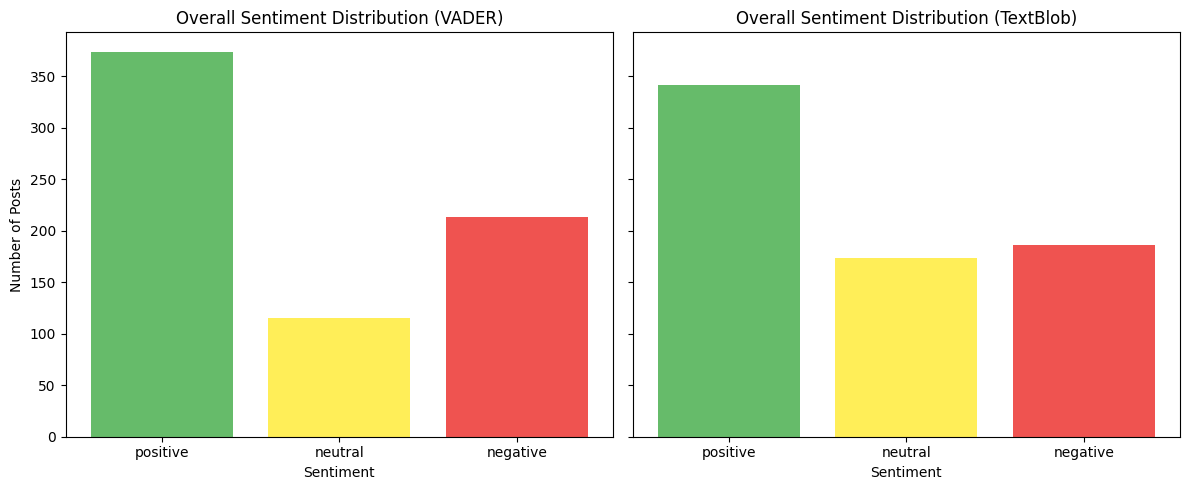

In [ ]:
import matplotlib.pyplot as plt

order = ["positive", "neutral", "negative"]
colors = ["#66bb6a", "#ffee58", "#ef5350"]

vc_vader = df["vader_label"].value_counts().reindex(order, fill_value=0)
vc_tb    = df["textblob_label"].value_counts().reindex(order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# VADER
axes[0].bar(order, vc_vader[order], color=colors)
axes[0].set_title("Overall Sentiment Distribution (VADER)")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Posts")
axes[0].tick_params(axis='x', rotation=0)

# TextBlob
axes[1].bar(order, vc_tb[order], color=colors)
axes[1].set_title("Overall Sentiment Distribution (TextBlob)")
axes[1].set_xlabel("Sentiment")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


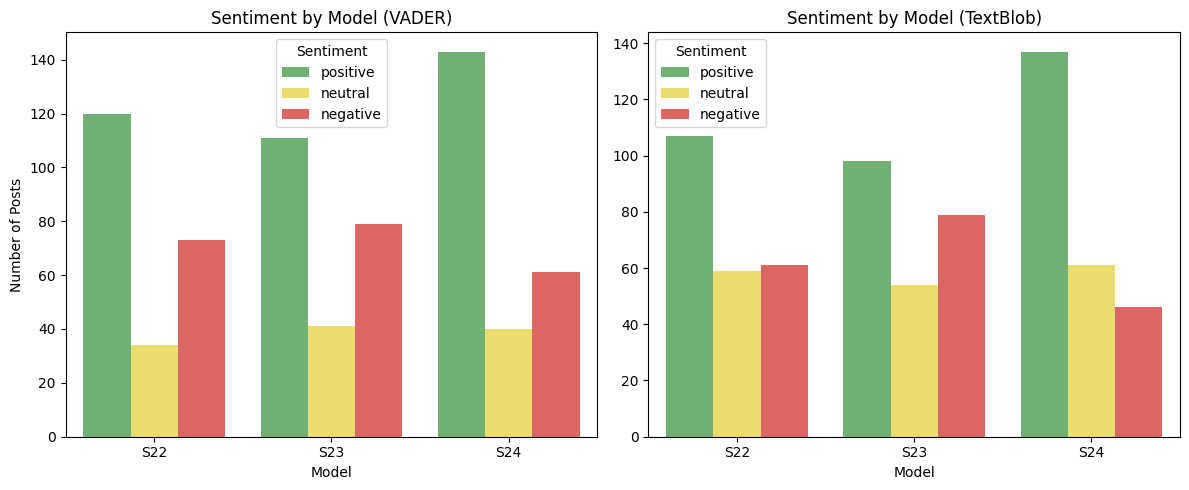

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["positive", "neutral", "negative"]
palette = {"positive":"#66bb6a","neutral":"#ffee58","negative":"#ef5350"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# VADER
sns.countplot(
    data=df, x="model", hue="vader_label",
    hue_order=order, palette=palette, ax=axes[0]
)
axes[0].set_title("Sentiment by Model (VADER)")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Number of Posts")
axes[0].legend(title="Sentiment")

# TextBlob
sns.countplot(
    data=df, x="model", hue="textblob_label",
    hue_order=order, palette=palette, ax=axes[1]
)
axes[1].set_title("Sentiment by Model (TextBlob)")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("")  # shared y
axes[1].legend(title="Sentiment")

plt.tight_layout()
plt.show()


Score Distributions

/tmp/ipython-input-3333940650.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-3333940650.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


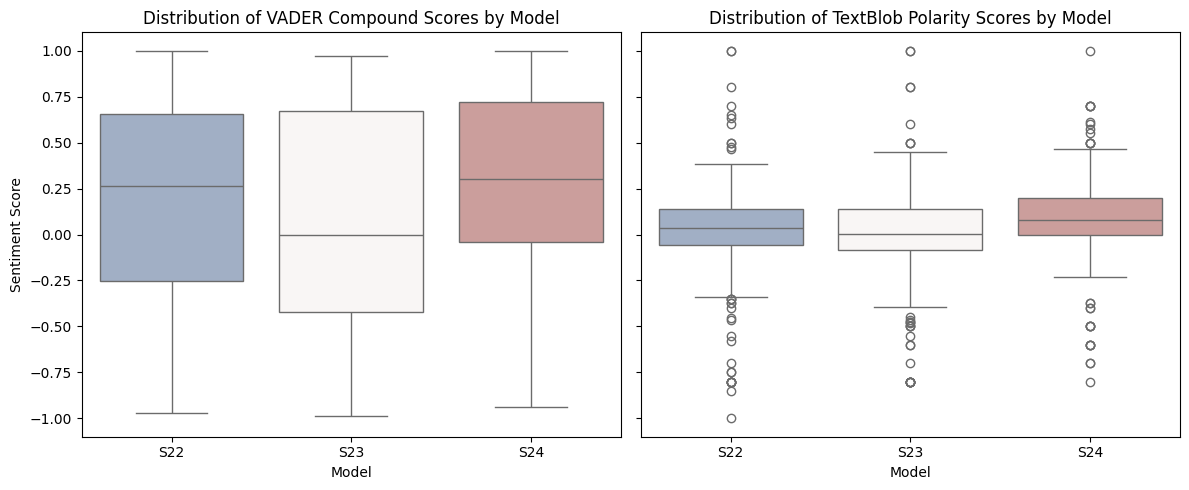

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# VADER
sns.boxplot(
    data=df, x="model", y="vader_compound",
    palette="vlag", ax=axes[0]
)
axes[0].set_title("Distribution of VADER Compound Scores by Model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Sentiment Score")

# TextBlob
sns.boxplot(
    data=df, x="model", y="textblob_polarity",
    palette="vlag", ax=axes[1]
)
axes[1].set_title("Distribution of TextBlob Polarity Scores by Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


Agreement between VADER and TextBlob Sentiment Scores

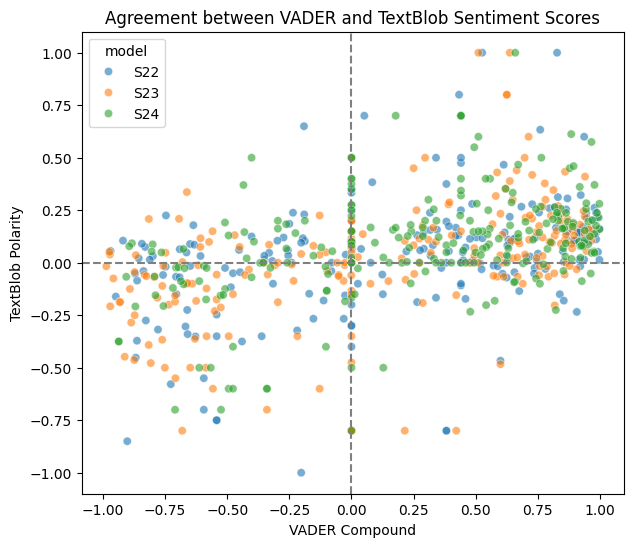

In [ ]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x="vader_compound", y="textblob_polarity",
                hue="model", alpha=0.6)
plt.title("Agreement between VADER and TextBlob Sentiment Scores")
plt.xlabel("VADER Compound")
plt.ylabel("TextBlob Polarity")
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.show()
